In [1]:
# ==========================================================
# CELL 1
# Import all required libraries
# ==========================================================

print("Starting cell #1")

import os
import json
import copy
import pickle
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn.utils import clip_grad_norm_
from torch.ao.quantization import quantize_dynamic

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    XLMRobertaConfig,
    XLMRobertaModel,
    get_linear_schedule_with_warmup
)

warnings.filterwarnings("ignore")

print("Executed cell #1")

Starting cell #1
Executed cell #1


In [2]:
# ==========================================================
# CELL 2
# Set paths, hyperparameters, and experiment settings
# Updated for Kaggle dataset discovery + supervised contrastive learning
# ==========================================================

print("Starting cell #2")

# -----------------------------
# Kaggle dataset file names
# -----------------------------
TRAIN_FILENAME = "train.csv"
VAL_FILENAME = "validation.csv"
TEST_FILENAME = "test.csv"

# Optional hint to prioritize the correct Kaggle dataset folder
# Example: if your dataset path contains ".../dataset/..."
DATASET_NAME_HINT = "dataset"

# -----------------------------
# Model settings
# -----------------------------
TEACHER_MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 128

# Student architecture
STUDENT_HIDDEN_SIZE = 384
STUDENT_NUM_LAYERS = 6
STUDENT_NUM_HEADS = 6
STUDENT_INTERMEDIATE_SIZE = 1536
DROPOUT = 0.1

# -----------------------------
# Multi-GPU batch settings
# -----------------------------
# With 2 GPUs, effective batch size = PER_GPU_BATCH_SIZE * 2
PER_GPU_BATCH_SIZE = 8
GRAD_CLIP = 1.0

# -----------------------------
# Training settings
# -----------------------------
TEACHER_EPOCHS = 2
STUDENT_EPOCHS = 3

TEACHER_LR = 2e-5
STUDENT_LR = 2e-5
WEIGHT_DECAY = 0.01

# -----------------------------
# Loss weights
# total_loss = CE + alpha*KD + beta*RowAlign + gamma*SupCon
# -----------------------------
ALPHA_KD = 0.7
BETA_ROW_ALIGN = 0.15
GAMMA_SUPCON = 0.15

TEMPERATURE_KD = 2.0
ROW_ALIGN_TEMPERATURE = 0.07
SUPCON_TEMPERATURE = 0.07

# -----------------------------
# Misc
# -----------------------------
SEED = 42
NUM_WORKERS = 2
SAVE_DIR = "/kaggle/working/multilingual_emotion_kd_contrastive"

os.makedirs(SAVE_DIR, exist_ok=True)

print("Executed cell #2")

Starting cell #2
Executed cell #2


In [3]:
# ==========================================================
# CELL 3
# Set random seeds, check GPUs, and configure effective batch size
# Modified for 2 T4 GPUs
# ==========================================================

print("Starting cell #3")

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

GPU_COUNT = torch.cuda.device_count() if torch.cuda.is_available() else 0
print("GPU count:", GPU_COUNT)

if torch.cuda.is_available():
    for i in range(GPU_COUNT):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

BATCH_SIZE = PER_GPU_BATCH_SIZE * max(1, GPU_COUNT)
print("Per-GPU batch size:", PER_GPU_BATCH_SIZE)
print("Effective total batch size:", BATCH_SIZE)

MULTI_GPU = GPU_COUNT > 1
print("Multi-GPU enabled:", MULTI_GPU)

print("Executed cell #3")

Starting cell #3
Using device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Per-GPU batch size: 8
Effective total batch size: 16
Multi-GPU enabled: True
Executed cell #3


In [4]:
# ==========================================================
# CELL 4
# Find Kaggle dataset CSV files automatically, load data,
# encode labels, and build flat + triplet datasets
# while KEEPING the original dataset column names
# ==========================================================

print("Starting cell #4")

from pathlib import Path
import re
import pandas as pd
from sklearn.preprocessing import LabelEncoder

REQUIRED_COLUMNS = [
    "Label",
    "Bengali",
    "Banglish",
    "English"
]

def resolve_kaggle_csv(filename, dataset_name_hint="dataset"):
    """
    Search Kaggle mounted folders and pick the best matching CSV file.
    Priority:
    1) paths containing dataset_name_hint
    2) paths under /kaggle/input
    3) alphabetical order
    """
    search_roots = [
        Path("/kaggle/input"),
        Path("/kaggle/working"),
        Path("/kaggle")
    ]

    matches = []
    for root in search_roots:
        if root.exists():
            matches.extend(root.rglob(filename))

    matches = sorted(set(str(p) for p in matches))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find {filename} under /kaggle/input or related Kaggle folders."
        )

    def score_path(path_str):
        score = 0
        path_lower = path_str.lower()

        if dataset_name_hint and dataset_name_hint.lower() in path_lower:
            score += 10
        if "/kaggle/input/" in path_lower:
            score += 5
        if path_lower.endswith("/" + filename.lower()):
            score += 1

        return score

    matches = sorted(matches, key=lambda x: (-score_path(x), x))
    chosen = matches[0]

    print(f"\nCandidates found for {filename}:")
    for p in matches[:10]:
        prefix = "->" if p == chosen else "  "
        print(f"{prefix} {p}")

    return chosen


TRAIN_CSV = resolve_kaggle_csv(TRAIN_FILENAME, DATASET_NAME_HINT)
VAL_CSV = resolve_kaggle_csv(VAL_FILENAME, DATASET_NAME_HINT)
TEST_CSV = resolve_kaggle_csv(TEST_FILENAME, DATASET_NAME_HINT)

print("\nResolved file paths:")
print("TRAIN_CSV =", TRAIN_CSV)
print("VAL_CSV   =", VAL_CSV)
print("TEST_CSV  =", TEST_CSV)


def normalize_colname(col):
    col = str(col).replace("\ufeff", "").strip().lower()
    col = re.sub(r"[\s\-/]+", "_", col)
    col = re.sub(r"_+", "_", col)
    return col.strip("_")


def load_dataframe(path):
    df = pd.read_csv(path)

    # Clean raw column names first
    df.columns = [str(c).replace("\ufeff", "").strip() for c in df.columns]

    # Robust matching, but final names stay as dataset schema names
    alias_map = {
        "label": "Label",
        "emotion_label": "Label",
        "emotion": "Label",

        "bengali": "Bengali",
        "bangla": "Bengali",
        "bangla_sentence": "Bengali",
        "bengali_sentence": "Bengali",

        "banglish": "Banglish",
        "banglish_sentence": "Banglish",

        "english": "English",
        "english_sentence": "English",
    }

    rename_map = {}
    for col in df.columns:
        norm = normalize_colname(col)
        if norm in alias_map:
            rename_map[col] = alias_map[norm]

    df = df.rename(columns=rename_map)

    missing_cols = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing_cols:
        raise ValueError(
            f"{path} is missing required columns: {missing_cols}\n"
            f"Available columns are: {list(df.columns)}"
        )

    df = df[REQUIRED_COLUMNS].copy()

    # No missing-value handling, as requested
    for col in REQUIRED_COLUMNS:
        df[col] = df[col].astype(str).str.strip()

    return df.reset_index(drop=True)


train_df = load_dataframe(TRAIN_CSV)
val_df = load_dataframe(VAL_CSV)
test_df = load_dataframe(TEST_CSV)

print("\nDetected dataset schema:")
print(train_df.columns.tolist())

label_encoder = LabelEncoder()
train_df["label_id"] = label_encoder.fit_transform(train_df["Label"])
val_df["label_id"] = label_encoder.transform(val_df["Label"])
test_df["label_id"] = label_encoder.transform(test_df["Label"])

num_labels = len(label_encoder.classes_)
print("\nNumber of emotion classes:", num_labels)
print("Emotion classes:", list(label_encoder.classes_))


def build_flat_classification_df(df):
    """
    Each row becomes 3 classification samples:
    Bengali, Banglish, English
    """
    records = []

    language_columns = [
        ("Bengali", "bengali"),
        ("Banglish", "banglish"),
        ("English", "english")
    ]

    for text_col, lang_name in language_columns:
        subset = df[["label_id", text_col]].copy()
        subset = subset.rename(columns={text_col: "text"})
        subset["language"] = lang_name
        records.append(subset)

    flat_df = pd.concat(records, axis=0).reset_index(drop=True)
    return flat_df


def build_triplet_alignment_df(df):
    """
    Each row stays as one multilingual triplet:
    (Bengali, Banglish, English)
    """
    triplet_df = df[
        ["label_id", "Bengali", "Banglish", "English"]
    ].copy().reset_index(drop=True)
    return triplet_df


flat_train_df = build_flat_classification_df(train_df)
flat_val_df = build_flat_classification_df(val_df)
flat_test_df = build_flat_classification_df(test_df)

triplet_train_df = build_triplet_alignment_df(train_df)
triplet_val_df = build_triplet_alignment_df(val_df)
triplet_test_df = build_triplet_alignment_df(test_df)

print(f"\nTrain rows: {len(train_df)}")
print(f"Validation rows: {len(val_df)}")
print(f"Test rows: {len(test_df)}")

print(f"Flat train samples: {len(flat_train_df)}")
print(f"Flat validation samples: {len(flat_val_df)}")
print(f"Flat test samples: {len(flat_test_df)}")

print(f"Triplet train samples: {len(triplet_train_df)}")
print(f"Triplet validation samples: {len(triplet_val_df)}")
print(f"Triplet test samples: {len(triplet_test_df)}")

print("Executed cell #4")

Starting cell #4

Candidates found for train.csv:
-> /kaggle/input/datasets/sajidruetcse21/dataset/train.csv

Candidates found for validation.csv:
-> /kaggle/input/datasets/sajidruetcse21/dataset/validation.csv

Candidates found for test.csv:
-> /kaggle/input/datasets/sajidruetcse21/dataset/test.csv

Resolved file paths:
TRAIN_CSV = /kaggle/input/datasets/sajidruetcse21/dataset/train.csv
VAL_CSV   = /kaggle/input/datasets/sajidruetcse21/dataset/validation.csv
TEST_CSV  = /kaggle/input/datasets/sajidruetcse21/dataset/test.csv

Detected dataset schema:
['Label', 'Bengali', 'Banglish', 'English']

Number of emotion classes: 6
Emotion classes: ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']

Train rows: 56067
Validation rows: 7929
Test rows: 16101
Flat train samples: 168201
Flat validation samples: 23787
Flat test samples: 48303
Triplet train samples: 56067
Triplet validation samples: 7929
Triplet test samples: 16101
Executed cell #4


In [5]:
# ==========================================================
# CELL 5
# Create tokenizer, Dataset classes, and DataLoaders
# Compatible with the dataset schema created in CELL 4
# ==========================================================

print("Starting cell #5")

tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL_NAME)


class FlatEmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        required_cols = ["text", "label_id", "language"]
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(
                f"FlatEmotionDataset is missing columns: {missing_cols}\n"
                f"Available columns: {list(df.columns)}"
            )

        self.texts = df["text"].astype(str).tolist()
        self.labels = df["label_id"].astype(int).tolist()
        self.languages = df["language"].astype(str).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoded = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in encoded.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item


class TripletEmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        # Support both the current schema from CELL 4
        # and older alternative column names
        bangla_col = self._find_column(df, ["Bengali", "bangla_sentence", "bengali_sentence", "bangla"])
        banglish_col = self._find_column(df, ["Banglish", "banglish_sentence", "banglish"])
        english_col = self._find_column(df, ["English", "english_sentence", "english"])

        if "label_id" not in df.columns:
            raise ValueError(
                f"TripletEmotionDataset requires 'label_id'. "
                f"Available columns: {list(df.columns)}"
            )

        self.bangla = df[bangla_col].astype(str).tolist()
        self.banglish = df[banglish_col].astype(str).tolist()
        self.english = df[english_col].astype(str).tolist()
        self.labels = df["label_id"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

        print(
            f"TripletEmotionDataset column mapping -> "
            f"Bangla: {bangla_col}, Banglish: {banglish_col}, English: {english_col}"
        )

    @staticmethod
    def _find_column(df, candidates):
        for col in candidates:
            if col in df.columns:
                return col
        raise ValueError(
            f"None of the expected columns were found: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )

    def encode_text(self, text):
        encoded = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {k: v.squeeze(0) for k, v in encoded.items()}

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        bangla_enc = self.encode_text(self.bangla[idx])
        banglish_enc = self.encode_text(self.banglish[idx])
        english_enc = self.encode_text(self.english[idx])

        item = {
            "bangla_input_ids": bangla_enc["input_ids"],
            "bangla_attention_mask": bangla_enc["attention_mask"],

            "banglish_input_ids": banglish_enc["input_ids"],
            "banglish_attention_mask": banglish_enc["attention_mask"],

            "english_input_ids": english_enc["input_ids"],
            "english_attention_mask": english_enc["attention_mask"],

            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

        return item


# -----------------------------
# Build Dataset objects
# -----------------------------
flat_train_dataset = FlatEmotionDataset(flat_train_df, tokenizer, MAX_LENGTH)
flat_val_dataset = FlatEmotionDataset(flat_val_df, tokenizer, MAX_LENGTH)
flat_test_dataset = FlatEmotionDataset(flat_test_df, tokenizer, MAX_LENGTH)

triplet_train_dataset = TripletEmotionDataset(triplet_train_df, tokenizer, MAX_LENGTH)
triplet_val_dataset = TripletEmotionDataset(triplet_val_df, tokenizer, MAX_LENGTH)
triplet_test_dataset = TripletEmotionDataset(triplet_test_df, tokenizer, MAX_LENGTH)


# -----------------------------
# Build DataLoader objects
# -----------------------------
loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available()
}

flat_train_loader = DataLoader(flat_train_dataset, shuffle=True, **loader_kwargs)
flat_val_loader = DataLoader(flat_val_dataset, shuffle=False, **loader_kwargs)
flat_test_loader = DataLoader(flat_test_dataset, shuffle=False, **loader_kwargs)

triplet_train_loader = DataLoader(triplet_train_dataset, shuffle=True, **loader_kwargs)
triplet_val_loader = DataLoader(triplet_val_dataset, shuffle=False, **loader_kwargs)
triplet_test_loader = DataLoader(triplet_test_dataset, shuffle=False, **loader_kwargs)


# -----------------------------
# Sanity checks
# -----------------------------
print("Tokenizer loaded.")
print("Flat train columns:", flat_train_df.columns.tolist())
print("Triplet train columns:", triplet_train_df.columns.tolist())
print("DataLoaders created successfully.")
print("Batch size used by each DataLoader:", BATCH_SIZE)

print("Executed cell #5")

Starting cell #5


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

TripletEmotionDataset column mapping -> Bangla: Bengali, Banglish: Banglish, English: English
TripletEmotionDataset column mapping -> Bangla: Bengali, Banglish: Banglish, English: English
TripletEmotionDataset column mapping -> Bangla: Bengali, Banglish: Banglish, English: English
Tokenizer loaded.
Flat train columns: ['label_id', 'text', 'language']
Triplet train columns: ['label_id', 'Bengali', 'Banglish', 'English']
DataLoaders created successfully.
Batch size used by each DataLoader: 16
Executed cell #5


In [6]:
# ==========================================================
# CELL 6
# Define student model, helper functions, initialize teacher/student,
# and wrap models with DataParallel when multiple GPUs are available
# ==========================================================

print("Starting cell #6")

def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


class StudentEmotionModel(nn.Module):
    def __init__(
        self,
        num_labels,
        student_hidden_size=384,
        num_hidden_layers=6,
        num_attention_heads=6,
        intermediate_size=1536,
        dropout=0.1
    ):
        super().__init__()

        self.arch_config = {
            "num_labels": num_labels,
            "student_hidden_size": student_hidden_size,
            "num_hidden_layers": num_hidden_layers,
            "num_attention_heads": num_attention_heads,
            "intermediate_size": intermediate_size,
            "dropout": dropout
        }

        config = XLMRobertaConfig(
            vocab_size=tokenizer.vocab_size,
            hidden_size=student_hidden_size,
            num_hidden_layers=num_hidden_layers,
            num_attention_heads=num_attention_heads,
            intermediate_size=intermediate_size,
            max_position_embeddings=514,
            hidden_dropout_prob=dropout,
            attention_probs_dropout_prob=dropout,
            pad_token_id=tokenizer.pad_token_id,
            bos_token_id=tokenizer.bos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

        self.encoder = XLMRobertaModel(config)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(student_hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        encoder_outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sentence_embedding = mean_pooling(
            encoder_outputs.last_hidden_state,
            attention_mask
        )

        logits = self.classifier(self.dropout(sentence_embedding))

        return {
            "embeddings": sentence_embedding,
            "logits": logits
        }


def get_base_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model


def count_parameters(model):
    base_model = get_base_model(model)
    total_params = sum(p.numel() for p in base_model.parameters())
    trainable_params = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
    return total_params, trainable_params


teacher_model = AutoModelForSequenceClassification.from_pretrained(
    TEACHER_MODEL_NAME,
    num_labels=num_labels
).to(device)

student_model = StudentEmotionModel(
    num_labels=num_labels,
    student_hidden_size=STUDENT_HIDDEN_SIZE,
    num_hidden_layers=STUDENT_NUM_LAYERS,
    num_attention_heads=STUDENT_NUM_HEADS,
    intermediate_size=STUDENT_INTERMEDIATE_SIZE,
    dropout=DROPOUT
).to(device)

if MULTI_GPU:
    teacher_model = nn.DataParallel(teacher_model)
    student_model = nn.DataParallel(student_model)
    print("Both teacher and student models are wrapped with nn.DataParallel")

teacher_total, teacher_trainable = count_parameters(teacher_model)
student_total, student_trainable = count_parameters(student_model)

print(f"Teacher total params: {teacher_total:,}")
print(f"Teacher trainable params: {teacher_trainable:,}")
print(f"Student total params: {student_total:,}")
print(f"Student trainable params: {student_trainable:,}")

print("Executed cell #6")

Starting cell #6


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Both teacher and student models are wrapped with nn.DataParallel
Teacher total params: 278,048,262
Teacher trainable params: 278,048,262
Student total params: 106,996,614
Student trainable params: 106,996,614
Executed cell #6


In [7]:
# ==========================================================
# CELL 7
# Define loss functions, utilities, and evaluation
# Updated to return full validation metrics for epoch-end printing
# ==========================================================

print("Starting cell #7")

classification_criterion = nn.CrossEntropyLoss()

def get_logits_from_model_output(outputs):
    if isinstance(outputs, dict):
        return outputs["logits"]
    if hasattr(outputs, "logits"):
        return outputs.logits
    if isinstance(outputs, (tuple, list)):
        for item in outputs:
            if torch.is_tensor(item) and item.dim() >= 2:
                return item
    raise ValueError("Could not extract logits from model outputs.")


def knowledge_distillation_loss(student_logits, teacher_logits, temperature=2.0):
    student_log_probs = F.log_softmax(student_logits / temperature, dim=-1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=-1)

    kd_loss = F.kl_div(
        student_log_probs,
        teacher_probs,
        reduction="batchmean"
    ) * (temperature ** 2)

    return kd_loss


class MultiPositiveRowAlignmentLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, emb_bangla, emb_banglish, emb_english):
        embeddings = torch.cat([emb_bangla, emb_banglish, emb_english], dim=0)
        embeddings = F.normalize(embeddings, p=2, dim=1)

        batch_size = emb_bangla.size(0)
        device_local = embeddings.device

        row_ids = torch.arange(batch_size, device=device_local).repeat(3)

        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        sim_matrix = sim_matrix - sim_matrix.max(dim=1, keepdim=True).values.detach()

        self_mask = torch.eye(sim_matrix.size(0), dtype=torch.bool, device=device_local)
        positive_mask = (row_ids.unsqueeze(0) == row_ids.unsqueeze(1)) & (~self_mask)

        exp_sim = torch.exp(sim_matrix) * (~self_mask).float()
        log_prob = sim_matrix - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        positive_mask_float = positive_mask.float()
        mean_log_prob_pos = (
            (positive_mask_float * log_prob).sum(dim=1) /
            positive_mask_float.sum(dim=1).clamp(min=1.0)
        )

        loss = -mean_log_prob_pos.mean()
        return loss


class SupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings, p=2, dim=1)
        labels = labels.contiguous().view(-1)

        device_local = embeddings.device
        n = embeddings.size(0)

        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        sim_matrix = sim_matrix - sim_matrix.max(dim=1, keepdim=True).values.detach()

        self_mask = torch.eye(n, dtype=torch.bool, device=device_local)
        positive_mask = (labels.unsqueeze(0) == labels.unsqueeze(1)) & (~self_mask)

        exp_sim = torch.exp(sim_matrix) * (~self_mask).float()
        log_prob = sim_matrix - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        positive_mask_float = positive_mask.float()
        mean_log_prob_pos = (
            (positive_mask_float * log_prob).sum(dim=1) /
            positive_mask_float.sum(dim=1).clamp(min=1.0)
        )

        loss = -mean_log_prob_pos.mean()
        return loss


row_alignment_criterion = MultiPositiveRowAlignmentLoss(
    temperature=ROW_ALIGN_TEMPERATURE
)

supcon_criterion = SupervisedContrastiveLoss(
    temperature=SUPCON_TEMPERATURE
)


@torch.no_grad()
def evaluate_classification_model(model, dataloader, device, teacher_mode=False):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_preds = []

    for batch in tqdm(dataloader, desc="Evaluating", leave=False):
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        if teacher_mode:
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                return_dict=False
            )
        else:
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        logits = get_logits_from_model_output(outputs)
        loss = classification_criterion(logits, labels)
        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

    avg_loss = total_loss / max(len(dataloader), 1)

    acc = accuracy_score(all_labels, all_preds)
    precision_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall_macro = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": all_labels,
        "y_pred": all_preds
    }

print("Executed cell #7")

Starting cell #7
Executed cell #7


In [8]:
# ==========================================================
# CELL 8
# Fine-tune the teacher model, then freeze it for distillation
# Updated epoch-end logging format
# ==========================================================

print("Starting cell #8")

teacher_optimizer = AdamW(
    teacher_model.parameters(),
    lr=TEACHER_LR,
    weight_decay=WEIGHT_DECAY
)

teacher_total_steps = len(flat_train_loader) * TEACHER_EPOCHS
teacher_scheduler = get_linear_schedule_with_warmup(
    teacher_optimizer,
    num_warmup_steps=int(0.1 * teacher_total_steps),
    num_training_steps=teacher_total_steps
)

best_teacher_f1 = -1.0
teacher_best_path = os.path.join(SAVE_DIR, "best_teacher.pt")

for epoch in range(TEACHER_EPOCHS):
    teacher_model.train()
    running_loss = 0.0

    progress_bar = tqdm(
        flat_train_loader,
        desc=f"Teacher Epoch {epoch + 1}/{TEACHER_EPOCHS}",
        leave=True
    )

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        teacher_optimizer.zero_grad()

        outputs = teacher_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            return_dict=False
        )

        loss = outputs[0]
        if loss.dim() > 0:
            loss = loss.mean()

        loss.backward()

        clip_grad_norm_(teacher_model.parameters(), GRAD_CLIP)

        teacher_optimizer.step()
        teacher_scheduler.step()

        running_loss += loss.item()

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}"
        })

    avg_train_loss = running_loss / max(len(flat_train_loader), 1)

    val_metrics = evaluate_classification_model(
        teacher_model,
        flat_val_loader,
        device,
        teacher_mode=True
    )

    print(f"\n===== Teacher Epoch {epoch + 1}/{TEACHER_EPOCHS} =====\n")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print("Validation Language: All")
    print(f"Validation Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Validation Precision: {val_metrics['precision_macro']:.4f}")
    print(f"Validation Recall: {val_metrics['recall_macro']:.4f}")
    print(f"Validation Macro F1: {val_metrics['macro_f1']:.4f}")
    print(f"Validation Weighted F1: {val_metrics['weighted_f1']:.4f}")

    if val_metrics["macro_f1"] > best_teacher_f1:
        best_teacher_f1 = val_metrics["macro_f1"]
        torch.save(get_base_model(teacher_model).state_dict(), teacher_best_path)
        print(f"Best teacher updated and saved to: {teacher_best_path}")

get_base_model(teacher_model).load_state_dict(
    torch.load(teacher_best_path, map_location=device)
)

teacher_model.eval()

for param in teacher_model.parameters():
    param.requires_grad = False

print(f"\nBest teacher validation macro F1: {best_teacher_f1:.4f}")
print("Teacher model frozen and ready for distillation.")

print("Executed cell #8")

Starting cell #8


Teacher Epoch 1/2:   0%|          | 0/10513 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1487 [00:00<?, ?it/s]


===== Teacher Epoch 1/2 =====

Train Loss: 1.1989
Validation Language: All
Validation Accuracy: 0.5984
Validation Precision: 0.6312
Validation Recall: 0.5964
Validation Macro F1: 0.5998
Validation Weighted F1: 0.6006
Best teacher updated and saved to: /kaggle/working/multilingual_emotion_kd_contrastive/best_teacher.pt


Teacher Epoch 2/2:   0%|          | 0/10513 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1487 [00:00<?, ?it/s]


===== Teacher Epoch 2/2 =====

Train Loss: 0.9171
Validation Language: All
Validation Accuracy: 0.6290
Validation Precision: 0.6296
Validation Recall: 0.6251
Validation Macro F1: 0.6270
Validation Weighted F1: 0.6283
Best teacher updated and saved to: /kaggle/working/multilingual_emotion_kd_contrastive/best_teacher.pt

Best teacher validation macro F1: 0.6270
Teacher model frozen and ready for distillation.
Executed cell #8


In [9]:
# ==========================================================
# CELL 9
# Train the student model using:
# classification + KD + row-level alignment + supervised contrastive loss
# Updated with live progress bar + full epoch-end validation logging
# ==========================================================

print("Starting cell #9")

student_optimizer = AdamW(
    student_model.parameters(),
    lr=STUDENT_LR,
    weight_decay=WEIGHT_DECAY
)

student_total_steps = len(triplet_train_loader) * STUDENT_EPOCHS
student_scheduler = get_linear_schedule_with_warmup(
    student_optimizer,
    num_warmup_steps=int(0.1 * student_total_steps),
    num_training_steps=student_total_steps
)

best_student_f1 = -1.0
student_best_path = os.path.join(SAVE_DIR, "best_student.pt")

for epoch in range(STUDENT_EPOCHS):
    student_model.train()

    total_epoch_loss = 0.0
    total_ce_loss = 0.0
    total_kd_loss = 0.0
    total_row_align_loss = 0.0
    total_supcon_loss = 0.0

    progress_bar = tqdm(
        triplet_train_loader,
        desc=f"Student Epoch {epoch + 1}/{STUDENT_EPOCHS}",
        leave=True
    )

    for batch in progress_bar:
        labels = batch["labels"].to(device, non_blocking=True)

        bangla_input_ids = batch["bangla_input_ids"].to(device, non_blocking=True)
        bangla_attention_mask = batch["bangla_attention_mask"].to(device, non_blocking=True)

        banglish_input_ids = batch["banglish_input_ids"].to(device, non_blocking=True)
        banglish_attention_mask = batch["banglish_attention_mask"].to(device, non_blocking=True)

        english_input_ids = batch["english_input_ids"].to(device, non_blocking=True)
        english_attention_mask = batch["english_attention_mask"].to(device, non_blocking=True)

        student_optimizer.zero_grad()

        out_bangla = student_model(
            input_ids=bangla_input_ids,
            attention_mask=bangla_attention_mask
        )
        out_banglish = student_model(
            input_ids=banglish_input_ids,
            attention_mask=banglish_attention_mask
        )
        out_english = student_model(
            input_ids=english_input_ids,
            attention_mask=english_attention_mask
        )

        emb_bangla = out_bangla["embeddings"]
        emb_banglish = out_banglish["embeddings"]
        emb_english = out_english["embeddings"]

        student_logits_all = torch.cat([
            out_bangla["logits"],
            out_banglish["logits"],
            out_english["logits"]
        ], dim=0)

        embeddings_all = torch.cat([
            emb_bangla,
            emb_banglish,
            emb_english
        ], dim=0)

        labels_all = labels.repeat(3)

        with torch.no_grad():
            teacher_bangla = teacher_model(
                input_ids=bangla_input_ids,
                attention_mask=bangla_attention_mask,
                return_dict=False
            )[0]

            teacher_banglish = teacher_model(
                input_ids=banglish_input_ids,
                attention_mask=banglish_attention_mask,
                return_dict=False
            )[0]

            teacher_english = teacher_model(
                input_ids=english_input_ids,
                attention_mask=english_attention_mask,
                return_dict=False
            )[0]

            teacher_logits_all = torch.cat([
                teacher_bangla,
                teacher_banglish,
                teacher_english
            ], dim=0)

        ce_loss = classification_criterion(student_logits_all, labels_all)

        kd_loss = knowledge_distillation_loss(
            student_logits_all,
            teacher_logits_all,
            temperature=TEMPERATURE_KD
        )

        row_align_loss = row_alignment_criterion(
            emb_bangla,
            emb_banglish,
            emb_english
        )

        supcon_loss = supcon_criterion(
            embeddings_all,
            labels_all
        )

        total_loss = (
            ce_loss
            + (ALPHA_KD * kd_loss)
            + (BETA_ROW_ALIGN * row_align_loss)
            + (GAMMA_SUPCON * supcon_loss)
        )

        total_loss.backward()
        clip_grad_norm_(student_model.parameters(), GRAD_CLIP)

        student_optimizer.step()
        student_scheduler.step()

        total_epoch_loss += total_loss.item()
        total_ce_loss += ce_loss.item()
        total_kd_loss += kd_loss.item()
        total_row_align_loss += row_align_loss.item()
        total_supcon_loss += supcon_loss.item()

        progress_bar.set_postfix({
            "total": f"{total_loss.item():.4f}",
            "ce": f"{ce_loss.item():.4f}",
            "kd": f"{kd_loss.item():.4f}",
            "row": f"{row_align_loss.item():.4f}",
            "supcon": f"{supcon_loss.item():.4f}"
        })

    avg_total_loss = total_epoch_loss / max(len(triplet_train_loader), 1)
    avg_ce_loss = total_ce_loss / max(len(triplet_train_loader), 1)
    avg_kd_loss = total_kd_loss / max(len(triplet_train_loader), 1)
    avg_row_align_loss = total_row_align_loss / max(len(triplet_train_loader), 1)
    avg_supcon_loss = total_supcon_loss / max(len(triplet_train_loader), 1)

    val_metrics = evaluate_classification_model(student_model, flat_val_loader, device)

    print(f"\n===== Epoch {epoch + 1}/{STUDENT_EPOCHS} =====\n")
    print(f"Train Loss: {avg_total_loss:.4f}")
    print(f"  Classification Loss: {avg_ce_loss:.4f}")
    print(f"  KD Loss: {avg_kd_loss:.4f}")
    print(f"  Row Alignment Loss: {avg_row_align_loss:.4f}")
    print(f"  SupCon Loss: {avg_supcon_loss:.4f}")
    print("Validation Language: All")
    print(f"Validation Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Validation Precision: {val_metrics['precision_macro']:.4f}")
    print(f"Validation Recall: {val_metrics['recall_macro']:.4f}")
    print(f"Validation Macro F1: {val_metrics['macro_f1']:.4f}")
    print(f"Validation Weighted F1: {val_metrics['weighted_f1']:.4f}")

    if val_metrics["macro_f1"] > best_student_f1:
        best_student_f1 = val_metrics["macro_f1"]
        torch.save(get_base_model(student_model).state_dict(), student_best_path)
        print(f"Best model updated and saved to: {student_best_path}")

get_base_model(student_model).load_state_dict(
    torch.load(student_best_path, map_location=device)
)
student_model.eval()

print(f"\nBest student validation macro F1: {best_student_f1:.4f}")

print("Executed cell #9")

Starting cell #9


Student Epoch 1/3:   0%|          | 0/3505 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1487 [00:00<?, ?it/s]


===== Epoch 1/3 =====

Train Loss: 3.3681
  Classification Loss: 1.4502
  KD Loss: 1.3126
  Row Alignment Loss: 2.7672
  SupCon Loss: 3.8931
Validation Language: All
Validation Accuracy: 0.5170
Validation Precision: 0.5280
Validation Recall: 0.5027
Validation Macro F1: 0.5039
Validation Weighted F1: 0.5077
Best model updated and saved to: /kaggle/working/multilingual_emotion_kd_contrastive/best_student.pt


Student Epoch 2/3:   0%|          | 0/3505 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1487 [00:00<?, ?it/s]


===== Epoch 2/3 =====

Train Loss: 2.6006
  Classification Loss: 1.1852
  KD Loss: 0.7314
  Row Alignment Loss: 2.2570
  SupCon Loss: 3.7665
Validation Language: All
Validation Accuracy: 0.5435
Validation Precision: 0.5501
Validation Recall: 0.5348
Validation Macro F1: 0.5335
Validation Weighted F1: 0.5363
Best model updated and saved to: /kaggle/working/multilingual_emotion_kd_contrastive/best_student.pt


Student Epoch 3/3:   0%|          | 0/3505 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1487 [00:00<?, ?it/s]


===== Epoch 3/3 =====

Train Loss: 2.4056
  Classification Loss: 1.1068
  KD Loss: 0.6034
  Row Alignment Loss: 2.1136
  SupCon Loss: 3.7293
Validation Language: All
Validation Accuracy: 0.5621
Validation Precision: 0.5633
Validation Recall: 0.5573
Validation Macro F1: 0.5578
Validation Weighted F1: 0.5588
Best model updated and saved to: /kaggle/working/multilingual_emotion_kd_contrastive/best_student.pt

Best student validation macro F1: 0.5578
Executed cell #9


Starting cell #10
Evaluating on test file: /kaggle/input/datasets/sajidruetcse21/dataset/test.csv


Evaluating:   0%|          | 0/3019 [00:00<?, ?it/s]

Test Accuracy: 0.5602
Test Macro F1: 0.5548

Classification Report:
              precision    recall  f1-score   support

       anger     0.4448    0.3750    0.4069      9153
     disgust     0.4757    0.6164    0.5370      7899
        fear     0.6698    0.5538    0.6063      4563
         joy     0.7148    0.7642    0.7387     10755
     sadness     0.5164    0.4974    0.5067      9837
    surprise     0.5564    0.5115    0.5330      6096

    accuracy                         0.5602     48303
   macro avg     0.5630    0.5530    0.5548     48303
weighted avg     0.5599    0.5602    0.5571     48303



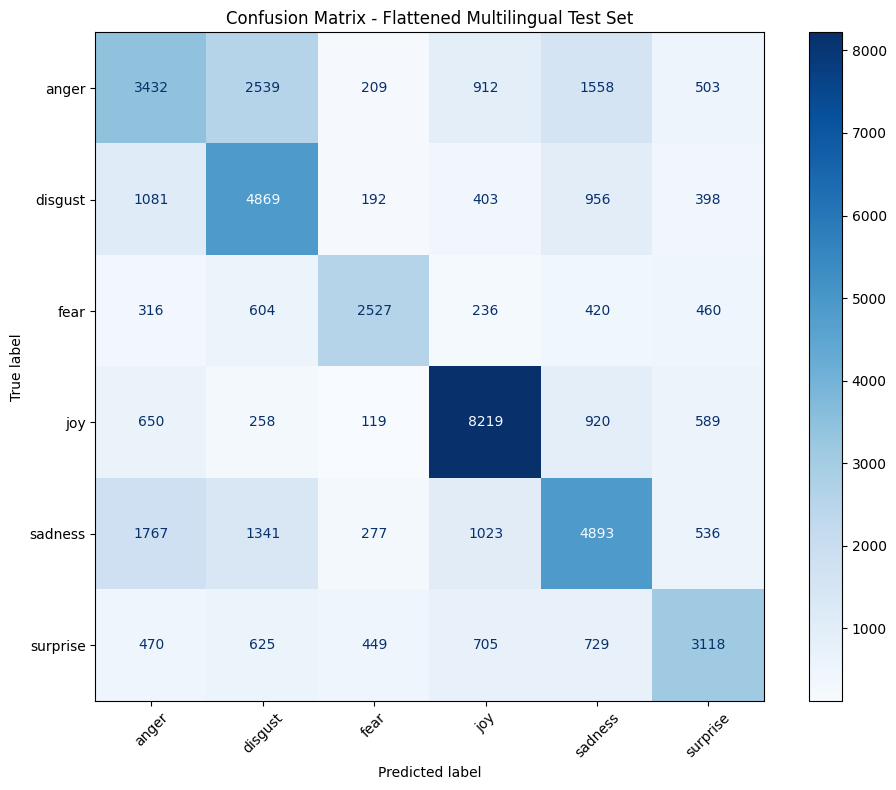

Executed cell #10


In [10]:
# ==========================================================
# CELL 10
# Evaluate the best student model on test.csv and compute
# accuracy, macro F1, confusion matrix, and classification report
# ==========================================================

print("Starting cell #10")

print("Evaluating on test file:", TEST_CSV)

test_metrics = evaluate_classification_model(student_model, flat_test_loader, device)

print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Test Macro F1: {test_metrics['macro_f1']:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        test_metrics["y_true"],
        test_metrics["y_pred"],
        target_names=label_encoder.classes_,
        digits=4
    )
)

cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"])

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix - Flattened Multilingual Test Set")
plt.tight_layout()
plt.show()

print("Executed cell #10")

In [11]:
# ==========================================================
# CELL 11
# Apply dynamic INT8 quantization, save artifacts,
# and define loading functions
# DataParallel-safe save/load version
# ==========================================================

print("Starting cell #11")

def save_student_artifacts(student_model, tokenizer, label_encoder, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    base_model = get_base_model(student_model)

    fp32_path = os.path.join(save_dir, "student_fp32_state_dict.pt")
    torch.save(base_model.state_dict(), fp32_path)

    config_path = os.path.join(save_dir, "student_arch_config.json")
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(base_model.arch_config, f, indent=2)

    tokenizer_dir = os.path.join(save_dir, "tokenizer")
    tokenizer.save_pretrained(tokenizer_dir)

    label_path = os.path.join(save_dir, "label_encoder.pkl")
    with open(label_path, "wb") as f:
        pickle.dump(label_encoder, f)

    quantized_student = quantize_dynamic(
        copy.deepcopy(base_model).cpu().eval(),
        {nn.Linear},
        dtype=torch.qint8
    )

    int8_path = os.path.join(save_dir, "student_int8_state_dict.pt")
    torch.save(quantized_student.state_dict(), int8_path)

    print(f"Saved FP32 model to: {fp32_path}")
    print(f"Saved INT8 model to: {int8_path}")
    print(f"Saved tokenizer to: {tokenizer_dir}")
    print(f"Saved label encoder to: {label_path}")
    print(f"Saved student config to: {config_path}")

    if os.path.exists(fp32_path):
        print(f"FP32 checkpoint size: {os.path.getsize(fp32_path) / (1024 * 1024):.2f} MB")
    if os.path.exists(int8_path):
        print(f"INT8 checkpoint size: {os.path.getsize(int8_path) / (1024 * 1024):.2f} MB")

    return quantized_student


def load_student_fp32(save_dir, device):
    config_path = os.path.join(save_dir, "student_arch_config.json")
    with open(config_path, "r", encoding="utf-8") as f:
        arch_config = json.load(f)

    tokenizer = AutoTokenizer.from_pretrained(os.path.join(save_dir, "tokenizer"))

    with open(os.path.join(save_dir, "label_encoder.pkl"), "rb") as f:
        label_encoder = pickle.load(f)

    model = StudentEmotionModel(**arch_config)
    state_dict = torch.load(
        os.path.join(save_dir, "student_fp32_state_dict.pt"),
        map_location=device
    )
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    if torch.cuda.is_available() and torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    return model, tokenizer, label_encoder


def load_student_int8(save_dir):
    config_path = os.path.join(save_dir, "student_arch_config.json")
    with open(config_path, "r", encoding="utf-8") as f:
        arch_config = json.load(f)

    tokenizer = AutoTokenizer.from_pretrained(os.path.join(save_dir, "tokenizer"))

    with open(os.path.join(save_dir, "label_encoder.pkl"), "rb") as f:
        label_encoder = pickle.load(f)

    model = StudentEmotionModel(**arch_config)
    model = quantize_dynamic(
        model.cpu().eval(),
        {nn.Linear},
        dtype=torch.qint8
    )

    state_dict = torch.load(
        os.path.join(save_dir, "student_int8_state_dict.pt"),
        map_location="cpu"
    )
    model.load_state_dict(state_dict)
    model.eval()

    return model, tokenizer, label_encoder


quantized_student_model = save_student_artifacts(
    student_model=student_model,
    tokenizer=tokenizer,
    label_encoder=label_encoder,
    save_dir=SAVE_DIR
)

print("Executed cell #11")

Starting cell #11
Saved FP32 model to: /kaggle/working/multilingual_emotion_kd_contrastive/student_fp32_state_dict.pt
Saved INT8 model to: /kaggle/working/multilingual_emotion_kd_contrastive/student_int8_state_dict.pt
Saved tokenizer to: /kaggle/working/multilingual_emotion_kd_contrastive/tokenizer
Saved label encoder to: /kaggle/working/multilingual_emotion_kd_contrastive/label_encoder.pkl
Saved student config to: /kaggle/working/multilingual_emotion_kd_contrastive/student_arch_config.json
FP32 checkpoint size: 408.20 MB
INT8 checkpoint size: 377.43 MB
Executed cell #11


In [12]:
# ==========================================================
# CELL 12
# Define inference function for single-text emotion prediction
# DataParallel-compatible version
# ==========================================================

print("Starting cell #12")

def predict_emotion(text, model, tokenizer, label_encoder, max_length=128, device=None):
    model.eval()

    if device is None:
        try:
            device = next(get_base_model(model).parameters()).device
        except StopIteration:
            device = torch.device("cpu")

    encoded = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt"
    )

    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(
            input_ids=encoded["input_ids"],
            attention_mask=encoded["attention_mask"]
        )
        logits = get_logits_from_model_output(outputs)
        probs = torch.softmax(logits, dim=-1).squeeze(0)

        pred_id = torch.argmax(probs).item()
        confidence = probs[pred_id].item()
        pred_label = label_encoder.inverse_transform([pred_id])[0]

    return pred_label, confidence


loaded_student_model, loaded_tokenizer, loaded_label_encoder = load_student_fp32(
    SAVE_DIR,
    device=device
)

sample_texts = [
    "আমি আজ খুব খুশি।",
    "Ami onek excited lagche ajke.",
    "I feel really happy today."
]

print("FP32 model predictions:")
for text in sample_texts:
    pred_label, confidence = predict_emotion(
        text,
        loaded_student_model,
        loaded_tokenizer,
        loaded_label_encoder,
        max_length=MAX_LENGTH,
        device=device
    )
    print(f"Text: {text}")
    print(f"Predicted Emotion: {pred_label} | Confidence: {confidence:.4f}")
    print("-" * 80)

loaded_int8_model, loaded_int8_tokenizer, loaded_int8_label_encoder = load_student_int8(SAVE_DIR)

print("\nINT8 model predictions:")
for text in sample_texts:
    pred_label, confidence = predict_emotion(
        text,
        loaded_int8_model,
        loaded_int8_tokenizer,
        loaded_int8_label_encoder,
        max_length=MAX_LENGTH,
        device=torch.device("cpu")
    )
    print(f"Text: {text}")
    print(f"Predicted Emotion: {pred_label} | Confidence: {confidence:.4f}")
    print("-" * 80)

print("Executed cell #12")

Starting cell #12
FP32 model predictions:
Text: আমি আজ খুব খুশি।
Predicted Emotion: joy | Confidence: 0.9687
--------------------------------------------------------------------------------
Text: Ami onek excited lagche ajke.
Predicted Emotion: joy | Confidence: 0.8750
--------------------------------------------------------------------------------
Text: I feel really happy today.
Predicted Emotion: joy | Confidence: 0.7918
--------------------------------------------------------------------------------

INT8 model predictions:
Text: আমি আজ খুব খুশি।
Predicted Emotion: joy | Confidence: 0.9684
--------------------------------------------------------------------------------
Text: Ami onek excited lagche ajke.
Predicted Emotion: joy | Confidence: 0.8787
--------------------------------------------------------------------------------
Text: I feel really happy today.
Predicted Emotion: joy | Confidence: 0.8007
--------------------------------------------------------------------------------